In [1]:
import os, glob, json
import numpy as np
import awkward
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

CLASS_NAMES = ["none", "chhad", "nhad", "gamma", "ele", "mu"]

In [2]:
def load_preds(pred_dir):
    files = sorted(glob.glob(os.path.join(pred_dir, "pred_*.parquet")))
    print(f"Loading {len(files)} files from {os.path.basename(pred_dir)}")
    if len(files) == 0:
        raise FileNotFoundError(f"No pred_*.parquet files found in {pred_dir}")
    arrays = []
    for f in files:
        try:
            arrays.append(awkward.from_parquet(f))
        except Exception as e:
            print(f"  skipping unreadable file {os.path.basename(f)}: {e}")
    data = awkward.concatenate(arrays)
    print(f"  -> {len(data)} events")
    return data

data_a = load_preds(os.path.expanduser("~/attention-v2/preds_step_100000/muoncollider_ttbar_pf/"))
data_g = load_preds(os.path.expanduser("~/muoncollider-attention-preds/muoncollider_ttbar_pf/"))
data_f = load_preds(os.path.expanduser("~/Downloads/attention-multi12/preds_step_75000/muoncollider_ttbar_pf/"))  

data_h = load_preds(os.path.expanduser("~/Downloads/attention-multi12/preds_step_22500/muoncollider_ttbar_pf/"))   

target_a, pred_a, cand_a = data_a["particles"]["target"], data_a["particles"]["pred"], data_a["particles"]["cand"]
target_g, pred_g, cand_g = data_g["particles"]["target"], data_g["particles"]["pred"], data_g["particles"]["cand"]
target_f, pred_f, cand_f = data_f["particles"]["target"], data_f["particles"]["pred"], data_f["particles"]["cand"]
target_h, pred_h, cand_h = data_h["particles"]["target"], data_h["particles"]["pred"], data_h["particles"]["cand"]

Loading 944 files from 
  skipping unreadable file pred_0_334.parquet: Parquet magic bytes not found in footer. Either the file is corrupted or this is not a parquet file.
  -> 943 events
Loading 1020 files from 
  -> 1020 events
Loading 84 files from 
  -> 1000 events
Loading 84 files from 
  -> 1000 events


## Training & validation loss

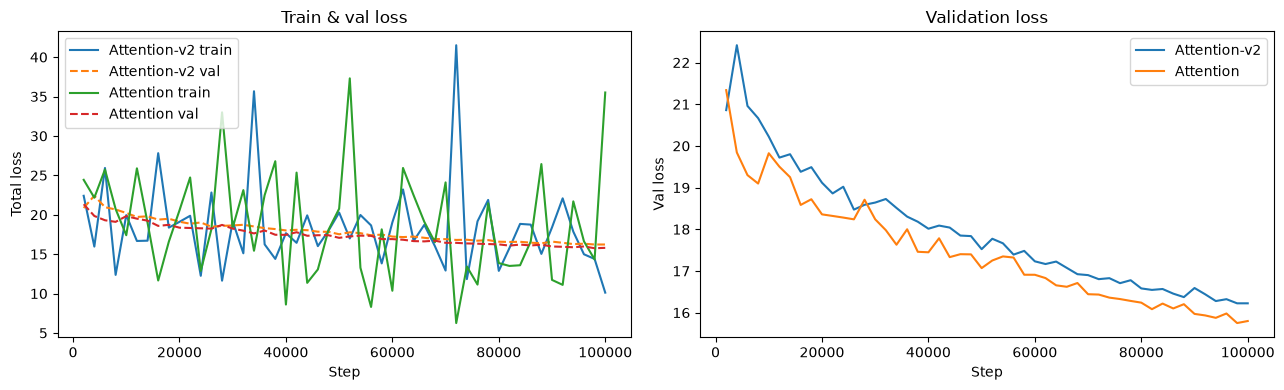

In [3]:
def load_history(history_dir):
    files = sorted(glob.glob(os.path.join(history_dir, "step_*.json")),
                   key=lambda f: int(os.path.basename(f).split("_")[1].split(".")[0]))
    steps, train_loss, val_loss = [], [], []
    for f in files:
        try:
            with open(f) as fh:
                d = json.load(fh)
            steps.append(int(os.path.basename(f).split("_")[1].split(".")[0]))
            train_loss.append(d["train"]["Total"])
            val_loss.append(d["valid"]["Total"])
        except (json.JSONDecodeError, KeyError):
            pass
    return np.array(steps), np.array(train_loss), np.array(val_loss)

v2_steps, v2_train, v2_val = load_history(os.path.expanduser("~/attention-v2/history"))
v1_steps, v1_train, v1_val = load_history(os.path.expanduser("~/muoncollider-attention-history"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(v2_steps, v2_train, label="Attention-v2 train")
axes[0].plot(v2_steps, v2_val,   label="Attention-v2 val", ls="--")
axes[0].plot(v1_steps, v1_train, label="Attention train")
axes[0].plot(v1_steps, v1_val,   label="Attention val",   ls="--")
axes[0].set(xlabel="Step", ylabel="Total loss", title="Train & val loss"); axes[0].legend()

axes[1].plot(v2_steps, v2_val, label="Attention-v2")
axes[1].plot(v1_steps, v1_val, label="Attention")
axes[1].set(xlabel="Step", ylabel="Val loss", title="Validation loss"); axes[1].legend()
plt.tight_layout()

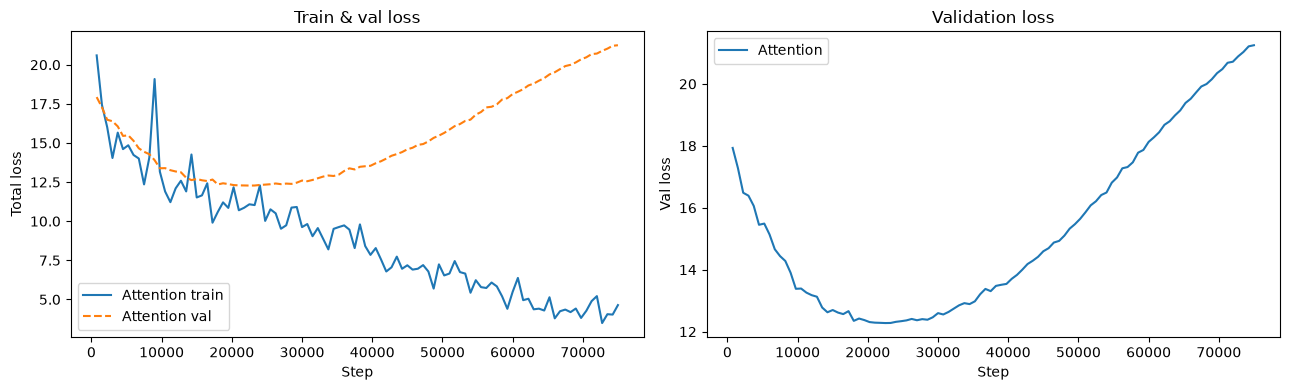

In [4]:
def load_history(history_dir):
    files = sorted(glob.glob(os.path.join(history_dir, "step_*.json")),
                   key=lambda f: int(os.path.basename(f).split("_")[1].split(".")[0]))
    steps, train_loss, val_loss = [], [], []
    for f in files:
        try:
            with open(f) as fh:
                d = json.load(fh)
            steps.append(int(os.path.basename(f).split("_")[1].split(".")[0]))
            train_loss.append(d["train"]["Total"])
            val_loss.append(d["valid"]["Total"])
        except (json.JSONDecodeError, KeyError):
            pass
    return np.array(steps), np.array(train_loss), np.array(val_loss)

v1_steps, v1_train, v1_val = load_history(os.path.expanduser("~/Downloads/attention-multi12/history"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(v1_steps, v1_train, label="Attention train")
axes[0].plot(v1_steps, v1_val,   label="Attention val",   ls="--")
axes[0].set(xlabel="Step", ylabel="Total loss", title="Train & val loss"); axes[0].legend()

axes[1].plot(v1_steps, v1_val, label="Attention")
axes[1].set(xlabel="Step", ylabel="Val loss", title="Validation loss"); axes[1].legend()
plt.tight_layout()

## Particle classification

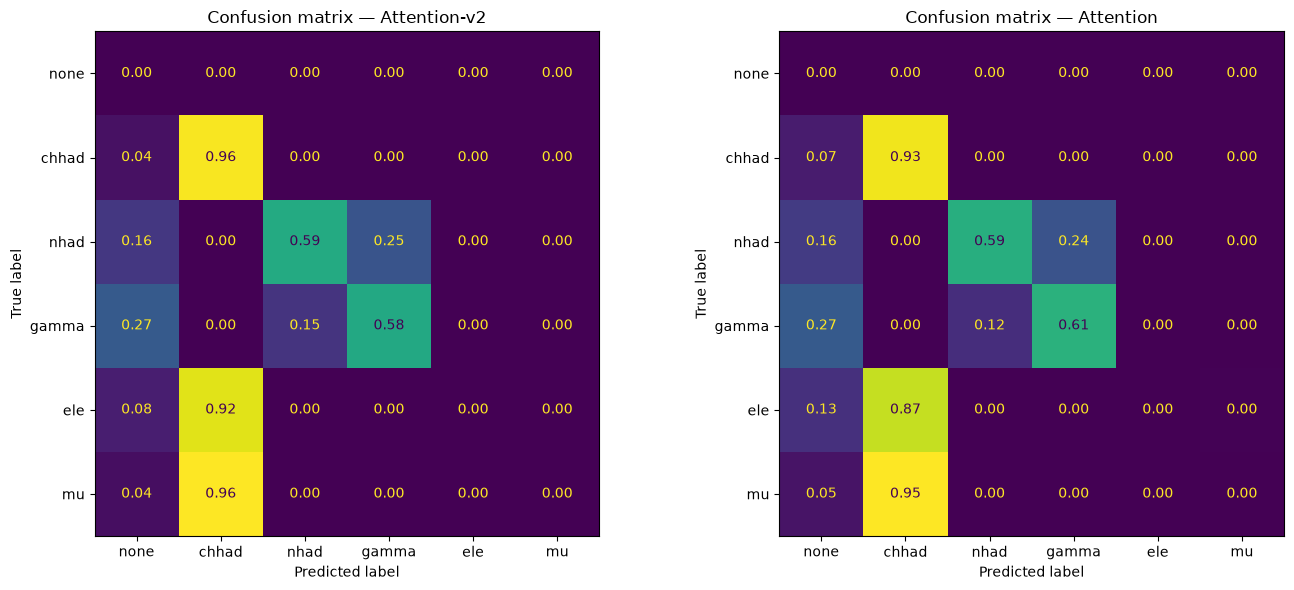

In [5]:
def make_cm(target, pred):
    msk = awkward.to_numpy(awkward.flatten(target["cls_id"])) != 0
    return confusion_matrix(
        awkward.to_numpy(awkward.flatten(target["cls_id"])[msk]),
        awkward.to_numpy(awkward.flatten(pred["cls_id"])[msk]),
        labels=list(range(6)), normalize="true"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm, title in zip(axes,
    [make_cm(target_a, pred_a), make_cm(target_g, pred_g)],
    ["Attention-v2", "Attention"]
):
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False, values_format=".2f")
    ax.set_title(f"Confusion matrix — {title}")
plt.tight_layout()

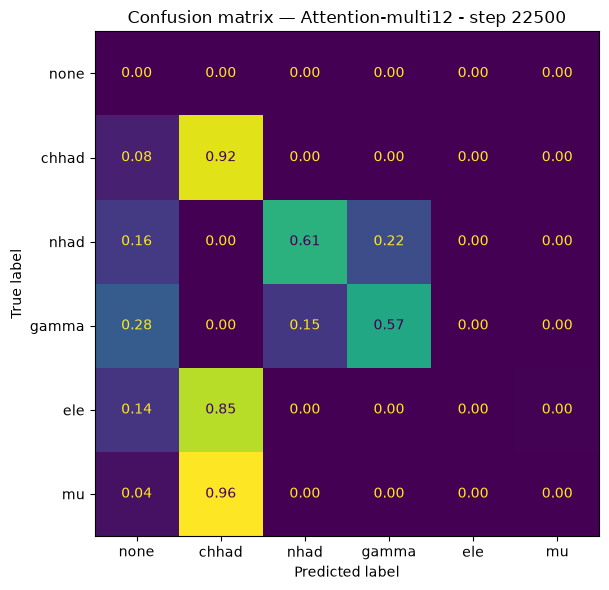

In [13]:
import awkward
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def make_cm(target, pred):
    msk = awkward.to_numpy(awkward.flatten(target["cls_id"])) != 0
    return confusion_matrix(
        awkward.to_numpy(awkward.flatten(target["cls_id"])[msk]),
        awkward.to_numpy(awkward.flatten(pred["cls_id"])[msk]),
        labels=list(range(6)), normalize="true"
    )

fig, ax = plt.subplots(figsize=(7, 6))
cm = make_cm(target_h, pred_h)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False, values_format=".2f")
ax.set_title("Confusion matrix — Attention-multi12 - step 22500")

plt.tight_layout()
plt.show()

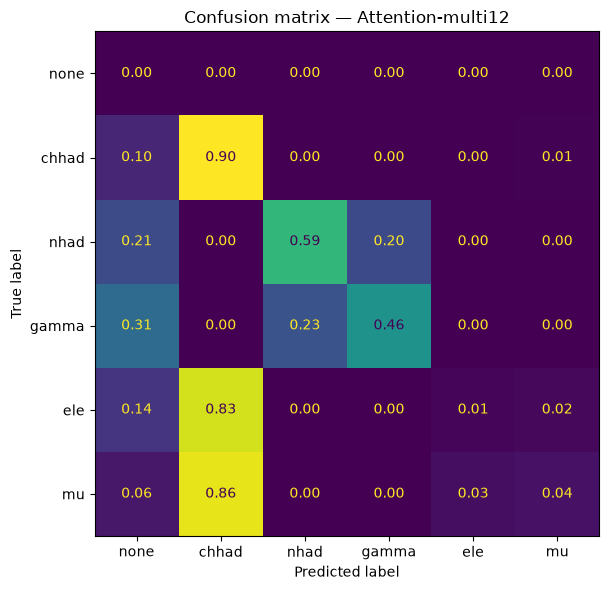

In [7]:
import awkward
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def make_cm(target, pred):
    msk = awkward.to_numpy(awkward.flatten(target["cls_id"])) != 0
    return confusion_matrix(
        awkward.to_numpy(awkward.flatten(target["cls_id"])[msk]),
        awkward.to_numpy(awkward.flatten(pred["cls_id"])[msk]),
        labels=list(range(6)), normalize="true"
    )

fig, ax = plt.subplots(figsize=(7, 6))
cm = make_cm(target_f, pred_f)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False, values_format=".2f")
ax.set_title("Confusion matrix — Attention-multi12")

plt.tight_layout()
plt.show()

## particles predicted as pT=0

Particles with pred label=None: 87,241
Particles with pred pT=0:       87,241
Both:                           87,241
None label but pT != 0:         0
pT=0 but label != None:         0
Fraction of None-label with pT=0: 1.0000
Fraction of pT=0 with None label: 1.0000


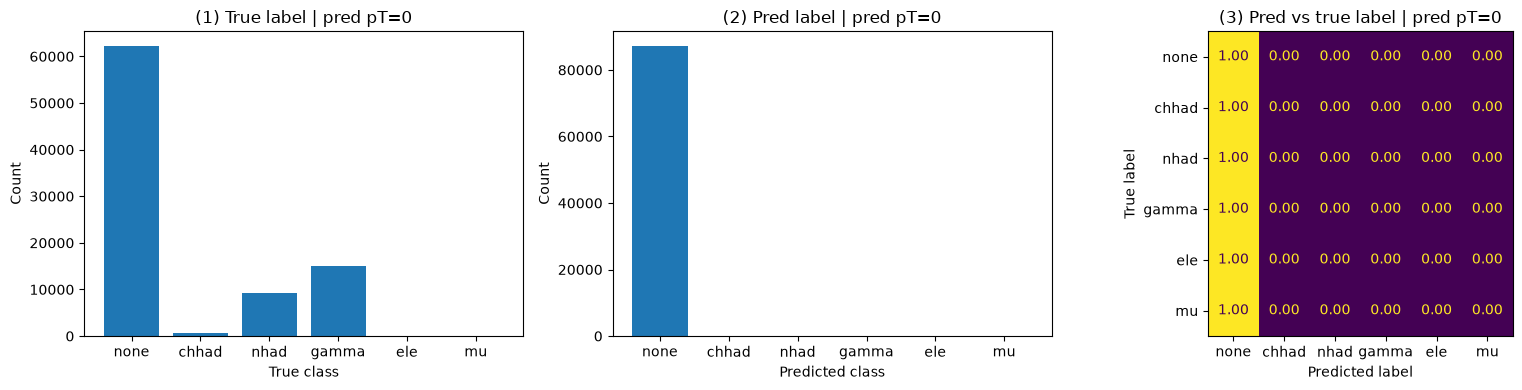

In [8]:
pred_cls_flat = awkward.to_numpy(awkward.flatten(pred_a["cls_id"]))
pred_pt_flat  = awkward.to_numpy(awkward.flatten(pred_a["pt"]))
true_cls_flat = awkward.to_numpy(awkward.flatten(target_a["cls_id"]))

msk_cls_none = pred_cls_flat == 0
msk_pt0      = pred_pt_flat  == 0.0

print(f"Particles with pred label=None: {msk_cls_none.sum():,}")
print(f"Particles with pred pT=0:       {msk_pt0.sum():,}")
print(f"Both:                           {(msk_cls_none & msk_pt0).sum():,}")
print(f"None label but pT != 0:         {(msk_cls_none & ~msk_pt0).sum():,}")
print(f"pT=0 but label != None:         {(msk_pt0 & ~msk_cls_none).sum():,}")
print(f"Fraction of None-label with pT=0: {(msk_cls_none & msk_pt0).sum() / msk_cls_none.sum():.4f}")
print(f"Fraction of pT=0 with None label: {(msk_cls_none & msk_pt0).sum() / msk_pt0.sum():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (1) true label of pred-pT=0 particles
axes[0].bar(range(6), [((true_cls_flat == c) & msk_pt0).sum() for c in range(6)])
axes[0].set_xticks(range(6)); axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set(xlabel="True class", ylabel="Count", title="(1) True label | pred pT=0")

# (2) predicted label of pred-pT=0 particles
axes[1].bar(range(6), [((pred_cls_flat == c) & msk_pt0).sum() for c in range(6)])
axes[1].set_xticks(range(6)); axes[1].set_xticklabels(CLASS_NAMES)
axes[1].set(xlabel="Predicted class", ylabel="Count", title="(2) Pred label | pred pT=0")

# (3) confusion matrix — full (all true classes)
cm = confusion_matrix(true_cls_flat[msk_pt0], pred_cls_flat[msk_pt0], labels=list(range(6)), normalize="true")
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=axes[2], colorbar=False, values_format=".2f")
axes[2].set_title("(3) Pred vs true label | pred pT=0")
plt.tight_layout()


## Kinematic response (true≠none, pred≠none)

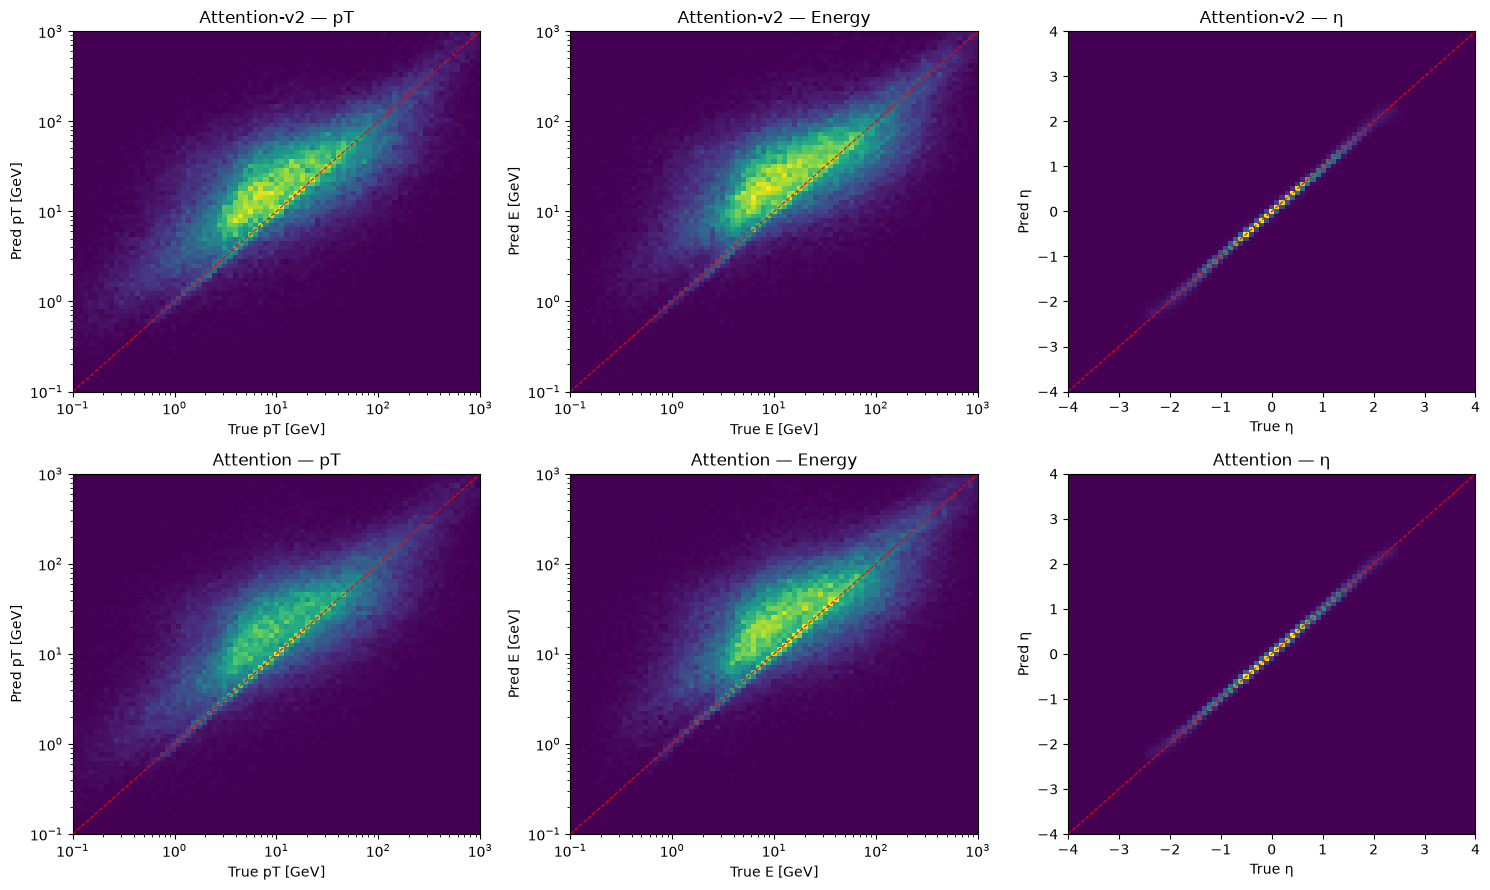

In [9]:
def get_kin(target, pred):
    true_cls = awkward.to_numpy(awkward.flatten(target["cls_id"]))
    pred_cls = awkward.to_numpy(awkward.flatten(pred["cls_id"]))
    msk = (true_cls != 0) & (pred_cls != 0)
    fl = lambda arr: awkward.to_numpy(awkward.flatten(arr))[msk]
    return fl(target["pt"]), fl(pred["pt"]), fl(target["energy"]), fl(pred["energy"]), fl(target["eta"]), fl(pred["eta"])

b_log = np.logspace(-1, 3, 80)
b_eta = np.linspace(-4, 4, 80)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for row, (label, target, pred) in enumerate([("Attention-v2", target_a, pred_a), ("Attention", target_g, pred_g)]):
    pt_t, pt_p, E_t, E_p, eta_t, eta_p = get_kin(target, pred)

    axes[row,0].hist2d(pt_t,  pt_p,  bins=(b_log, b_log))
    axes[row,0].set_xscale("log"); axes[row,0].set_yscale("log")
    axes[row,0].plot([0.1,1e3],[0.1,1e3], "r--", lw=0.8)
    axes[row,0].set(xlabel="True pT [GeV]", ylabel="Pred pT [GeV]", title=f"{label} — pT")

    axes[row,1].hist2d(E_t,   E_p,   bins=(b_log, b_log))
    axes[row,1].set_xscale("log"); axes[row,1].set_yscale("log")
    axes[row,1].plot([0.1,1e3],[0.1,1e3], "r--", lw=0.8)
    axes[row,1].set(xlabel="True E [GeV]",  ylabel="Pred E [GeV]",  title=f"{label} — Energy")

    axes[row,2].hist2d(eta_t, eta_p, bins=(b_eta, b_eta))
    axes[row,2].plot([-4,4],[-4,4], "r--", lw=0.8)
    axes[row,2].set(xlabel="True η", ylabel="Pred η", title=f"{label} — η")

plt.tight_layout()

## MET

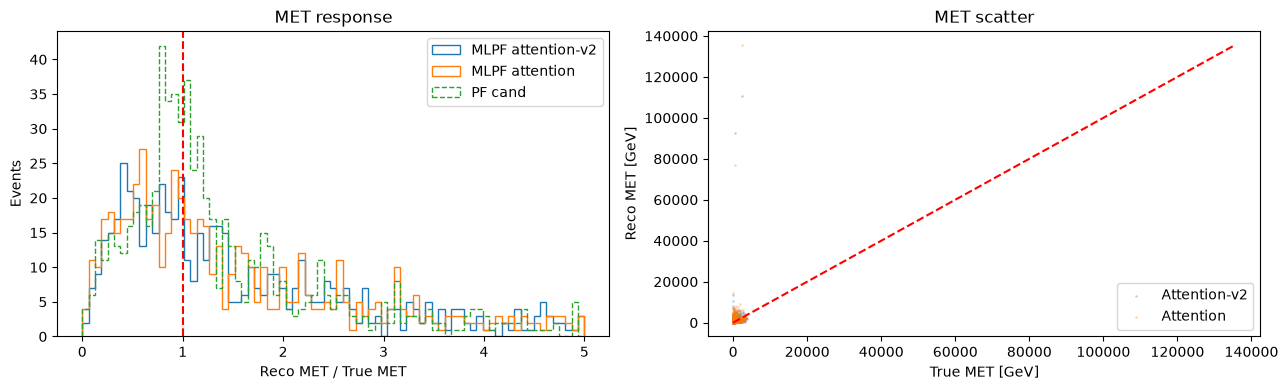

In [10]:
def compute_met(p):
    px = awkward.to_numpy(awkward.sum(p["pt"] * p["cos_phi"] * (p["cls_id"] != 0), axis=1))
    py = awkward.to_numpy(awkward.sum(p["pt"] * p["sin_phi"] * (p["cls_id"] != 0), axis=1))
    return np.sqrt(px**2 + py**2)

met_true_a = awkward.to_numpy(data_a["genmet"])
met_true_g = awkward.to_numpy(data_g["genmet"])
met_pred_a, met_pred_g = compute_met(pred_a), compute_met(pred_g)
met_cand_a = compute_met(cand_a)

b = np.linspace(0, 5, 80)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(met_pred_a / np.clip(met_true_a, 0.1, None), bins=b, histtype="step", label="MLPF attention-v2")
axes[0].hist(met_pred_g / np.clip(met_true_g, 0.1, None), bins=b, histtype="step", label="MLPF attention")
axes[0].hist(met_cand_a / np.clip(met_true_a, 0.1, None), bins=b, histtype="step", label="PF cand", ls="--")
axes[0].axvline(1.0, color="red", ls="--")
axes[0].set(xlabel="Reco MET / True MET", ylabel="Events", title="MET response"); axes[0].legend()

lim = max(met_true_a.max(), met_pred_a.max(), met_pred_g.max())
axes[1].scatter(met_true_a, met_pred_a, marker=".", alpha=0.2, s=5, label="Attention-v2")
axes[1].scatter(met_true_g, met_pred_g, marker=".", alpha=0.2, s=5, label="Attention")
axes[1].plot([0, lim], [0, lim], "r--")
axes[1].set(xlabel="True MET [GeV]", ylabel="Reco MET [GeV]", title="MET scatter"); axes[1].legend()
plt.tight_layout()

## Jet pT response

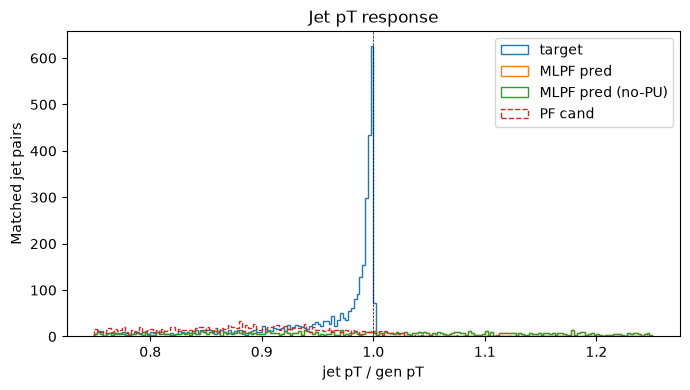

In [11]:
def jet_pt(jets): return np.sqrt(jets["x"]**2 + jets["y"]**2)

def matched_pt(jets, mj, key):
    return awkward.to_numpy(awkward.flatten(jet_pt(jets[key][mj[key]]), axis=1))

mj = data_a["matched_jets"]; j = data_a["jets"]
ret = {
    "target_genpt":  matched_pt(j, mj["gen_to_target"], "gen"),
    "target_recopt": matched_pt(j, mj["gen_to_target"], "target"),
    "pred_genpt":    matched_pt(j, mj["gen_to_pred"],   "gen"),
    "pred_recopt":   matched_pt(j, mj["gen_to_pred"],   "pred"),
    "nopu_genpt":    matched_pt(j, mj["gen_to_pred_nopu"], "gen"),
    "nopu_recopt":   matched_pt(j, mj["gen_to_pred_nopu"], "pred_nopu"),
    "cand_genpt":    matched_pt(j, mj["gen_to_cand"],   "gen"),
    "cand_recopt":   matched_pt(j, mj["gen_to_cand"],   "cand"),
}

b_ratio = np.linspace(0.75, 1.25, 201)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ret["target_recopt"] / ret["target_genpt"], bins=b_ratio, histtype="step", label="target")
ax.hist(ret["pred_recopt"]   / ret["pred_genpt"],   bins=b_ratio, histtype="step", label="MLPF pred")
ax.hist(ret["nopu_recopt"]   / ret["nopu_genpt"],   bins=b_ratio, histtype="step", label="MLPF pred (no-PU)")
ax.hist(ret["cand_recopt"]   / ret["cand_genpt"],   bins=b_ratio, histtype="step", label="PF cand", ls="--")
ax.axvline(1.0, color="k", ls="--", lw=0.5)
ax.set(xlabel="jet pT / gen pT", ylabel="Matched jet pairs", title="Jet pT response"); ax.legend()
plt.tight_layout()

## jet pT response vs gen pT (2D)

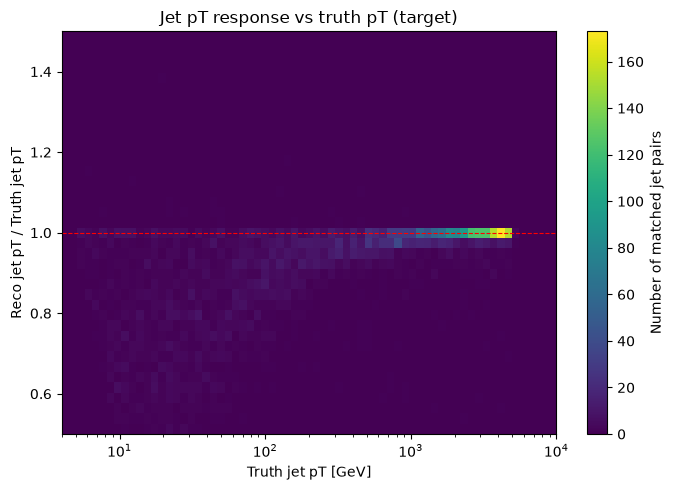

In [12]:
b_genpt = np.logspace(0, 4, 80) # 1 to 1000 GeV 
b_ratio = np.linspace(0.5, 1.5, 40) 
genpt = ret["target_genpt"] 
response = ret["target_recopt"] / genpt # keep only pT > 1 GeV for log scale 
mask = genpt >= 1 
fig, ax = plt.subplots(figsize=(7, 5)) 
h, xe, ye, img = ax.hist2d( genpt[mask], response[mask], bins=(b_genpt, b_ratio) ) 
plt.colorbar(img, ax=ax, label="Number of matched jet pairs") 
ax.axhline(1.0, color="red", ls="--", lw=0.8) 
ax.set_xscale("log") 
ax.set( xlabel="Truth jet pT [GeV]", ylabel="Reco jet pT / Truth jet pT", title="Jet pT response vs truth pT (target)" ) 
ax.set_xlim(4, 10000) 
plt.tight_layout()